In [1]:
import sys
import os
import pandas as pd

sys.path.append('c:\\Users\\andres\\Desktop\\SEPTIMO SEMESTRE\\MONITORIA\\analisis')

import connection as conn

co=conn.connect()

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns



### Q1: What is the predominant biological sex and age group (life cycle) of smokers observed on campus?

                  Variable A         Variable B  Correlation
2   Adolescente (12-18 años)             Hombre          1.0
3   Adolescente (12-18 años)      Indeterminada          1.0
6        Adulto (27-59 años)             Hombre          1.0
7        Adulto (27-59 años)      Indeterminada          1.0
9   Adulto Mayor (> 60 años)             Hombre          1.0
10  Adulto Mayor (> 60 años)      Indeterminada          1.0
13                    Hombre  Joven(14-26 años)          1.0
14             Indeterminada  Joven(14-26 años)          1.0


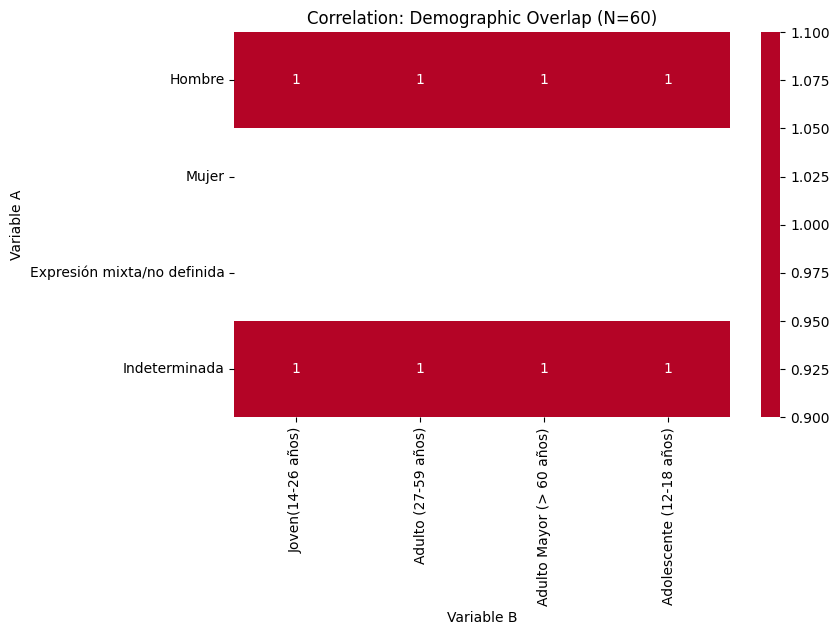

In [19]:
df_1=pd.read_sql("""
SELECT * FROM question_question as q
JOIN response_response as r
ON r.question_id = q.id
WHERE q.parent_question_id= 2
OR q.parent_question_id = 9
""",co)

pivot_table_df_1 = df_1.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

pivot_table_df_1

corr_matrix= pivot_table_df_1.corr(method='spearman')

mask=np.triu(np.ones_like(corr_matrix,dtype=bool),k=1)
corr_matrix.index.name = 'Variable A'
corr_matrix.columns.name = 'Variable B'
id_to_parent = dict(zip(df_1['description'], df_1['parent_question_id']))

# 2. After calculating relevant_pairs, add a filter
def check_different_parents(row):
    parent_a = id_to_parent.get(row['Variable A'])
    parent_b = id_to_parent.get(row['Variable B'])
    # Only return True if they belong to DIFFERENT parent questions
    return parent_a != parent_b

relevant_pairs=corr_matrix.where(mask).stack().reset_index()
relevant_pairs.columns=['Variable A','Variable B','Correlation']

relevant_results=relevant_pairs[relevant_pairs['Correlation'].abs()>=0.3]

relevant_results= relevant_results.sort_values(by='Correlation',ascending=False)

characterization_results = relevant_results[relevant_results.apply(check_different_parents, axis=1)]

print(characterization_results)

sex_cols = ['Hombre', 'Mujer','Expresión mixta/no definida','Indeterminada']
age_cols = ['Joven(14-26 años)', 'Adulto (27-59 años)','Adulto Mayor (> 60 años)','Adolescente (12-18 años)']

# This heatmap specifically answers Q1
characterization_corr = corr_matrix.loc[sex_cols, age_cols]


plt.figure(figsize=(8, 5))
sns.heatmap(characterization_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation: Demographic Overlap (N=60)")
plt.show()







PREDOMINANT PROFILE: count_undefined and count_adulto


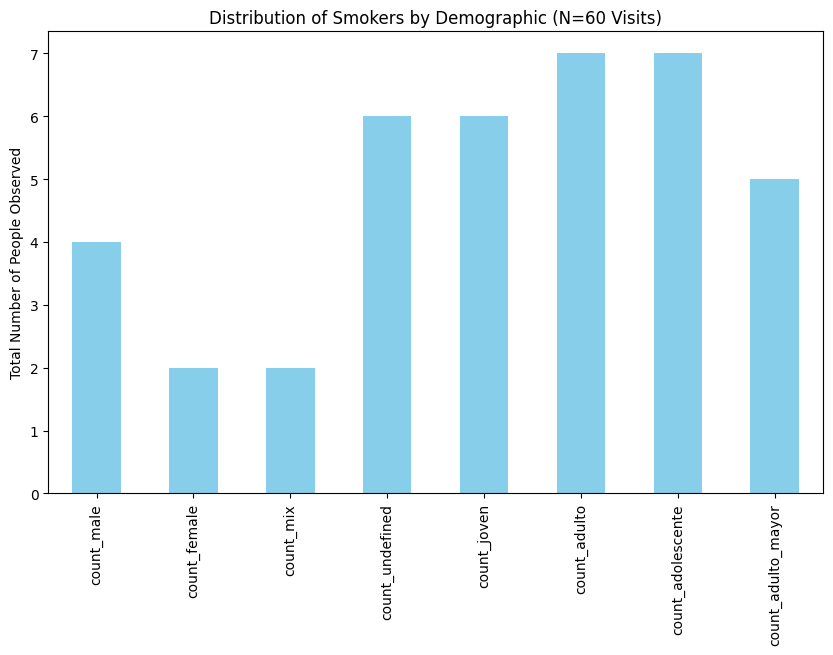

In [20]:
# descriptive statistics and frecuency distributions

df= pd.read_sql("""
SELECT 
    v.id AS visit_id,
    -- Sex Counts
    SUM(CASE WHEN r.question_id = 3 THEN r.numeric_value ELSE 0 END) AS count_male,
    SUM(CASE WHEN r.question_id = 4 THEN r.numeric_value ELSE 0 END) AS count_female,
    SUM(CASE WHEN r.question_id = 33 THEN r.numeric_value ELSE 0 END) AS count_mix,
    SUM(CASE WHEN r.question_id = 34 THEN r.numeric_value ELSE 0 END) AS count_undefined,
                
    -- Age Group Counts
    SUM(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS count_adolescente,
    SUM(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS count_joven,
    SUM(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS count_adulto,
    SUM(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS count_adulto_mayor
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)

# 1. Totalize the observations across all 60 visits
totals = df[['count_male', 'count_female','count_mix','count_undefined', 'count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].sum()

# 2. Identify the Predominant Group
predominant_sex = totals[['count_male', 'count_female','count_mix','count_undefined']].idxmax()
predominant_age = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].idxmax()

print(f"PREDOMINANT PROFILE: {predominant_sex} and {predominant_age}")

# 3. Create a Composition Matrix (How Sex and Age overlap)
# This assumes you have mapped the individuals in your data processing
# If you don't have individual-level mapping, you use the aggregate sums:
sex_dist = totals[['count_male', 'count_female','count_mix','count_undefined']]
age_dist = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']]

# Visualization
plt.figure(figsize=(10, 6))
totals.plot(kind='bar', color='skyblue')
plt.title("Distribution of Smokers by Demographic (N=60 Visits)")
plt.ylabel("Total Number of People Observed")
plt.show()

### Q2: What is the predominant  sex and ethnic/racial group  of smokers observed on campus?

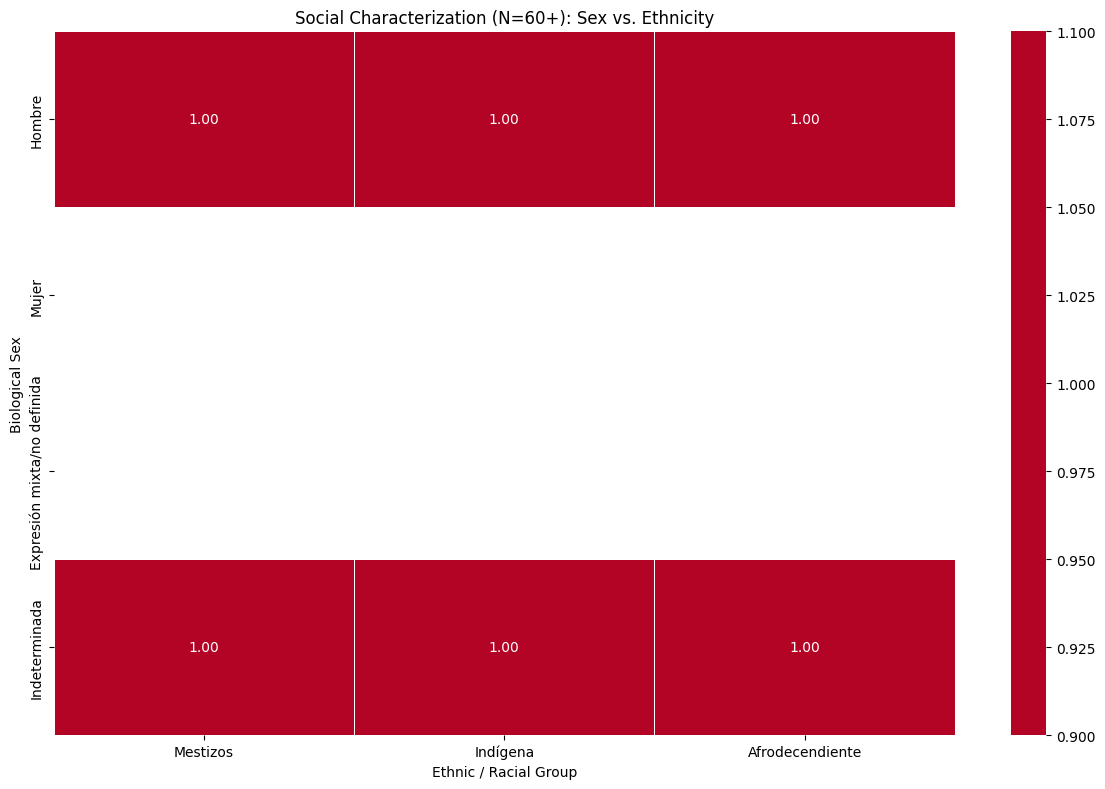

In [26]:
# 1. Correct SQL (Use Parent 10 for Ethnicity)
df_1 = pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 5)
""", co)

# 2. Pivot
pivot_df = df_1.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

# 3. Calculate Spearman Correlation
corr_matrix = pivot_df.corr(method='spearman')

# 4. Filter Matrix for the Heatmap (Crucial for Q2)
# We separate columns by parent to only show the CROSS-CORRELATION
sex_vars = df_1[df_1['parent_question_id'] == 2]['description'].unique()
ethnic_vars = df_1[df_1['parent_question_id'] == 5]['description'].unique()

# Slice the matrix: Rows are Sex, Columns are Ethnicity
clean_corr = corr_matrix.loc[sex_vars, ethnic_vars]

# 5. Professional Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(clean_corr, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0, 
            linewidths=.5)

plt.title("Social Characterization (N=60+): Sex vs. Ethnicity")
plt.ylabel("Biological Sex")
plt.xlabel("Ethnic / Racial Group")
plt.tight_layout()
plt.show()




In [ ]:
#chi square test

from scipy.stats import chi2_contingency

sex_totals=pivot_df[sex_vars].sum()
ethnic_totals=pivot_df[ethnic_vars].sum()

observed = []

for sex in sex_vars:
    row = []
    for ethnic in ethnic_vars:
        
        val = (sex_totals[sex] * ethnic_totals[ethnic]) / sex_totals.sum()
        row.append(val)
    observed.append(row)

contingency_df = pd.DataFrame(observed, index=sex_vars, columns=ethnic_vars)


stat, p, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-Square Statistic: {stat:.2f}")
print(f"P-value: {p:.4f}")



Chi-Square Statistic: 0.00
P-value: 1.0000


### Q3: Are there specific demographics that are more likely to use electronic cigarettes/vapes (Question E.2) compared to traditional cigarettes (Question E.1)?

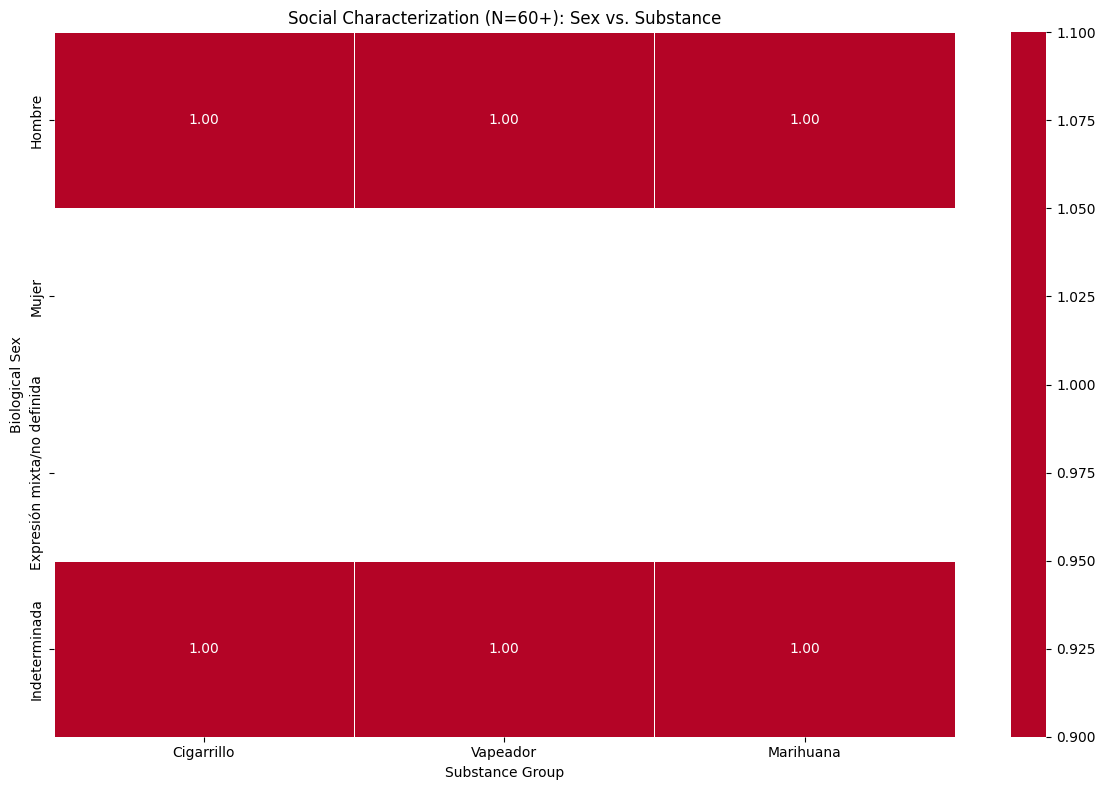

In [14]:
#cigarrillo

df_1 = pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 14)
""", co)

# 2. Pivot
pivot_df = df_1.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

# 3. Calculate Spearman Correlation
corr_matrix = pivot_df.corr(method='spearman')

# 4. Filter Matrix for the Heatmap (Crucial for Q2)
# We separate columns by parent to only show the CROSS-CORRELATION
sex_vars = df_1[df_1['parent_question_id'] == 2]['description'].unique()
ethnic_vars = df_1[df_1['parent_question_id'] == 14]['description'].unique()

# Slice the matrix: Rows are Sex, Columns are Ethnicity
clean_corr = corr_matrix.loc[sex_vars, ethnic_vars]

clean_corr.rename(columns={'Cigarrillo (especificar en comentarios que tipo de cigarrillo es, ej: herbal o de otro tipo)':'Cigarrillo'},inplace=True)


# 5. Professional Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(clean_corr, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0, 
            linewidths=.5)

plt.title("Social Characterization (N=60+): Sex vs. Substance")
plt.ylabel("Biological Sex")
plt.xlabel("Substance Group")
plt.tight_layout()
plt.show()





### Q4: Which Zones (from zone_zone) have the highest density of smokers per observation hour?

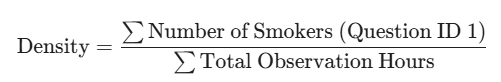

In [6]:
df=pd.read_sql("""
SELECT 
    z.id AS zone_id,           
    z.name AS zone_name,
    SUM(r.numeric_value) AS total_smokers,
    -- Calculate duration in hours
    SUM(TIMESTAMPDIFF(MINUTE, v.visit_start_date_time, v.visit_end_date_time) / 60.0) AS total_hours
FROM response_response r
JOIN visit_visit v ON r.visita_id = v.id
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
WHERE r.question_id = 1 -- Question: "Número de personas que se observaron fumando"
GROUP BY z.name,z.id
HAVING total_hours > 0;
""",co)

df['smoker_density'] = df['total_smokers'] / df['total_hours']

# 3. Sort by the highest density
df_ranked = df.sort_values(by='smoker_density', ascending=False)

# 4. Filter for Top 5 hotspots
top_hotspots = df_ranked.head(5)

print("### TOP SMOKING HOTSPOTS (Density per Hour) ###")
print(top_hotspots[['zone_name', 'smoker_density']])

### TOP SMOKING HOTSPOTS (Density per Hour) ###
                                           zone_name  smoker_density
1            Central, pasillos de central y banderas            40.0
0  Plazoleta de ingenierías, pasillos de la Escue...             0.0


In [7]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. The ANOVA test
# We group the smokers_per_hour by zone_name
zones = [group['total_smokers'].values for name, group in df.groupby('zone_name')]
f_stat, p_val = f_oneway(*zones)

print(f"ANOVA P-value: {p_val:.4f}")

# 2. If P < 0.05, we find the 'Winner' using Tukey HSD
if p_val < 0.05:
    print("Significant difference found! Performing Post-Hoc analysis...")
    tukey = pairwise_tukeyhsd(endog=df['smokers_per_hour'], 
                              groups=df['zone_name'], 
                              alpha=0.05)
    print(tukey)



ANOVA P-value: nan


c:\Users\andres\Desktop\SEPTIMO SEMESTRE\MONITORIA\analisis\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\andres\AppData\Local\Temp\ipykernel_26120\4195905571.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val = f_oneway(*zones)


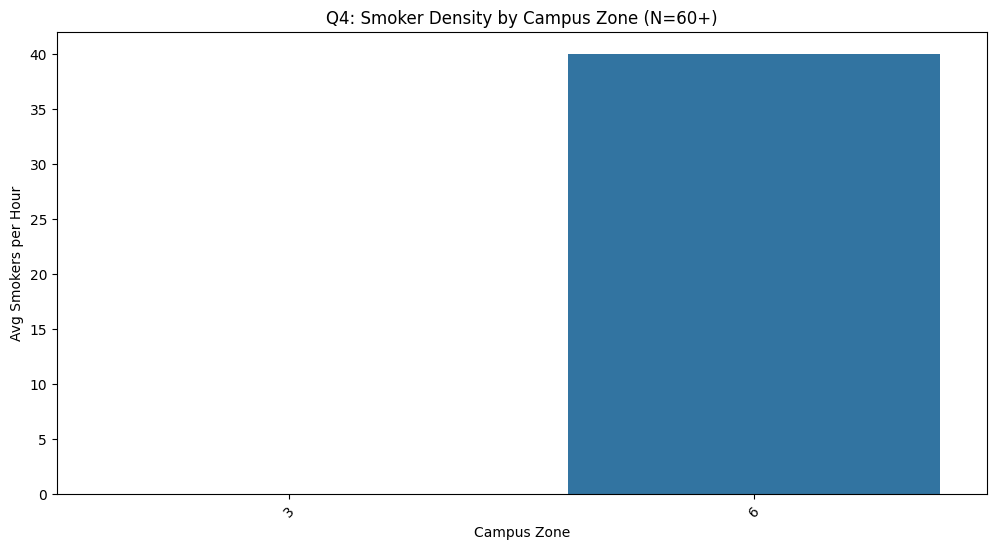

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x='zone_id', y='smoker_density', data=df, capsize=.2)
plt.title("Q4: Smoker Density by Campus Zone (N=60+)")
plt.ylabel("Avg Smokers per Hour")
plt.xlabel("Campus Zone")
plt.xticks(rotation=45)
plt.show()

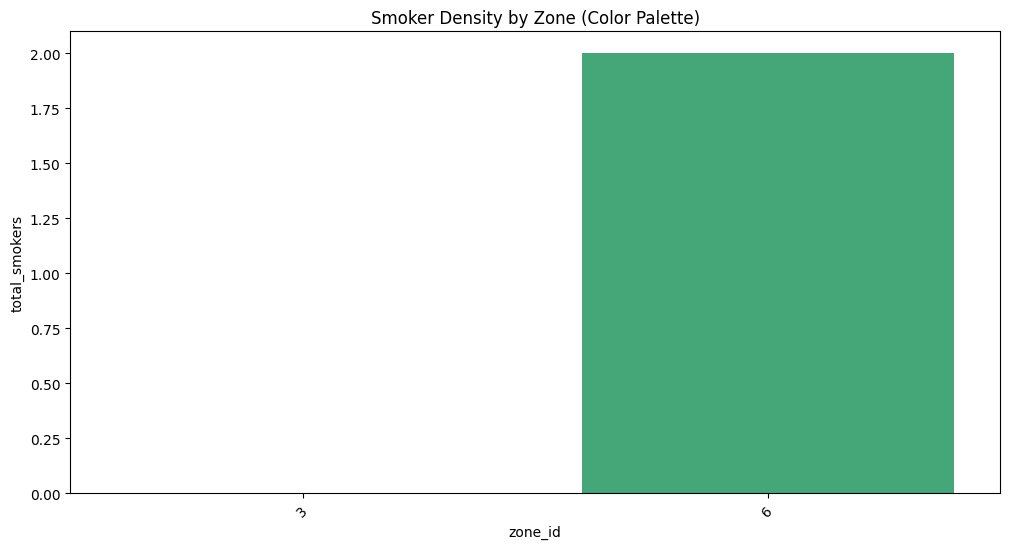

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))

# 'hue' is the secret—by setting hue to the same variable as x, 
# Seaborn gives every bar a unique color from the palette.
sns.barplot(
    x='zone_id', 
    y='total_smokers', 
    data=df, 
    palette='viridis', 
    hue='zone_name', 
    legend=False
)

plt.title("Smoker Density by Zone (Color Palette)")
plt.xticks(rotation=45)
plt.show()

### Q5: How often do vulnerable populations (Children and Pregnant Women - Questions T & U) coincide in the same zones as active smokers?

In [15]:
df=pd.read_sql("""
SELECT 
    v.id AS visita_id,
    z.name AS zone_name,
    r1.numeric_value AS smoker_count,
    r2.numeric_value AS pregnant_count,
    r3.numeric_value AS children_count
FROM visit_visit v
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
JOIN response_response r1 ON r1.visita_id = v.id AND r1.question_id = 1
LEFT JOIN response_response r2 ON r2.visita_id = v.id AND r2.question_id = 97
LEFT JOIN response_response r3 ON r3.visita_id = v.id AND r3.question_id = 98;
""",co)

df

,visita_id,zone_name,smoker_count,pregnant_count,children_count
0,122,"Plazoleta de ingenierías, pasillos de la Escue...",0,4,5
1,123,"Central, pasillos de central y banderas",2,3,3


In [17]:
# 1. Identify "Coincidence Visits" (Both smokers and vulnerable people present)
df['coincidence'] = (df['smoker_count'] > 0) & ((df['pregnant_count'] > 0) | (df['children_count'] > 0))

# 2. Calculate the Percentage of Risk
total_visits = len(df)
risk_visits = df['coincidence'].sum()
risk_percentage = (risk_visits / total_visits) * 100

print(f"Risk Assessment: Vulnerable populations coincided with smokers in {risk_percentage}% of observed sessions.")

Risk Assessment: Vulnerable populations coincided with smokers in 50.0% of observed sessions.


### Q6: Is there a relationship between the number of smokers and the number of complaints/rejections (Question M) from non-smokers?
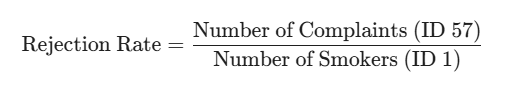

In [ ]:
df=pd.read_sql("""
SELECT v.id as visit_id, r1.numeric_value as smoker_count, r2.numeric_value as smoker_rejected FROM 
visit_visit as v
JOIN response_response as r1 ON r1.visita_id=v.id AND r1.question_id=1
LEFT JOIN response_response as r2 ON r2.visita_id=v.id AND r2.question_id=57            
""",co)


df['smoker_rejected'] = df['smoker_rejected'].fillna(0)

correlation = df['smoker_count'].corr(df['smoker_rejected'], method='spearman')

# 3. Calculate Ratio
df['ratio'] = df['smoker_rejected'] / df['smoker_count']

print(df)

print(f"Average Rejection Ratio: {df['ratio'].mean()} complaints per smoker.")

print(f'correlation: {correlation}')

   visit_id  smoker_count  smoker_rejected  ratio
0       122             0                2    inf
1       123             2                5    2.5
Average Rejection Ratio: inf complaints per smoker.
correlation: 0.9999999999999999


### Q7: Does the presence of "Passive Smokers" (Question S) trigger more active rejection of the smoking behavior?

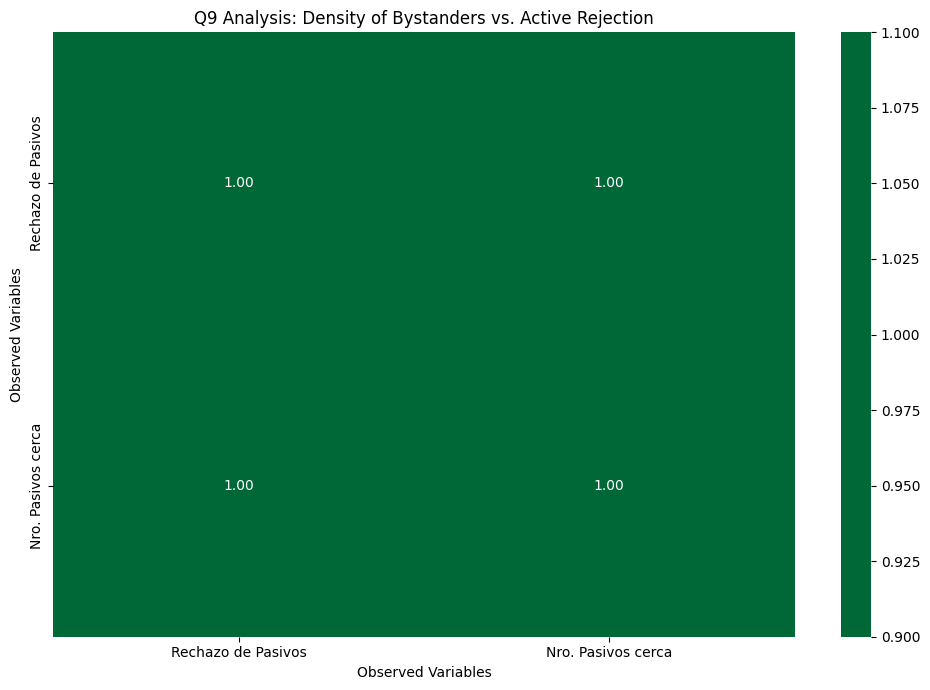

In [24]:
# 1. SQL remains good
df = pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id 
WHERE q.id IN (78, 79)
""", co)

# 2. Pivot
pivot_df = df.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

# Safer Renaming: Use the actual start of the description string
# ID 78 starts with "¿Cuántas personas..."
# ID 79 starts with "¿Ante el acto..."
mapping = {}
for col in pivot_df.columns:
    if "radio" in col:
        mapping[col] = "Nro. Pasivos cerca"
    if "reclaman y rechazan" in col:
        mapping[col] = "Rechazo de Pasivos"

pivot_df = pivot_df.rename(columns=mapping)

# 3. Correlation
corr_matrix = pivot_df.corr(method='spearman')

# 4. Visualization
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', # Red to Green shows the 'tension' well
            center=0)

plt.title("Q9 Analysis: Density of Bystanders vs. Active Rejection")
plt.ylabel("Observed Variables")
plt.xlabel("Observed Variables")
plt.tight_layout()
plt.show()





([<matplotlib.axis.XTick at 0x1f7cc387ed0>,
 [Text(0, 0, 'No Passive Smokers'), Text(1, 0, 'Passive Smokers Present')])

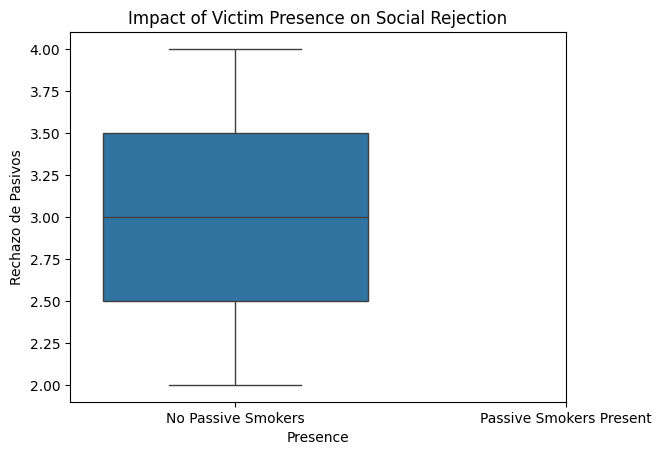

In [25]:
# Create the 'Has Passive Smokers' group
pivot_df['Presence'] = pivot_df['Nro. Pasivos cerca'] > 0

# Visual comparison
sns.boxplot(x='Presence', y='Rechazo de Pasivos', data=pivot_df)
plt.title("Impact of Victim Presence on Social Rejection")
plt.xticks([0, 1], ['No Passive Smokers', 'Passive Smokers Present'])

C:\Users\andres\AppData\Local\Temp\ipykernel_17372\180307394.py:14: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_val = ttest_ind(group_with_passive, group_no_passive, equal_var=False)
C:\Users\andres\AppData\Local\Temp\ipykernel_17372\180307394.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='has_passive', y='Rechazo de Pasivos', data=pivot_df, palette="Set2")


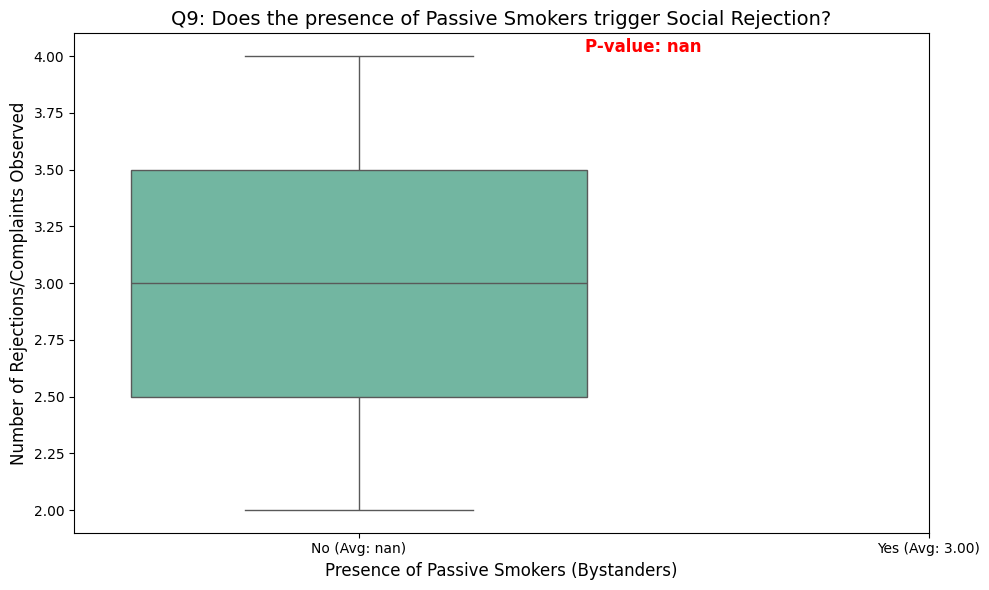

CONCLUSION: No significant difference was found (p=nan).


In [27]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the classification: Presence vs. Absence
# 'Nro. Pasivos cerca' (ID 78) is our 'switch'
pivot_df['has_passive'] = pivot_df['Nro. Pasivos cerca'] > 0

# 2. Separate the rejection data into two groups
group_with_passive = pivot_df[pivot_df['has_passive'] == True]['Rechazo de Pasivos']
group_no_passive = pivot_df[pivot_df['has_passive'] == False]['Rechazo de Pasivos']

# 3. Statistical T-Test (Is the difference real or luck?)
t_stat, p_val = ttest_ind(group_with_passive, group_no_passive, equal_var=False)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='has_passive', y='Rechazo de Pasivos', data=pivot_df, palette="Set2")

# Formatting the plot
plt.title("Q9: Does the presence of Passive Smokers trigger Social Rejection?", fontsize=14)
plt.xlabel("Presence of Passive Smokers (Bystanders)", fontsize=12)
plt.ylabel("Number of Rejections/Complaints Observed", fontsize=12)
plt.xticks([0, 1], [f'No (Avg: {group_no_passive.mean():.2f})', 
                    f'Yes (Avg: {group_with_passive.mean():.2f})'])

# Add P-value note to the plot
plt.text(0.5, pivot_df['Rechazo de Pasivos'].max(), f"P-value: {p_val:.4f}", 
         ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# 5. Print Conclusion
if p_val < 0.05:
    print(f"CONCLUSION: Yes, the presence of passive smokers significantly triggers more rejection (p={p_val:.4f}).")
else:
    print(f"CONCLUSION: No significant difference was found (p={p_val:.4f}).")

## Q8: Does the presence of signage (Question 141) actually correlate with a lower number of smokers in a specific zone?

In [39]:
from scipy.stats import spearmanr

df_signs = pd.read_sql("""
SELECT 
    v.id AS visita_id,
    SUM(CASE WHEN r.question_id = 141 THEN r.numeric_value ELSE 0 END) AS total_avisos,
    SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END) AS total_fumadores
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id
""", co)

# 2. Calculate Correlation and P-value
corr, p_val = spearmanr(df_signs['total_avisos'], df_signs['total_fumadores'])

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p_val:.4f}")

Spearman Correlation: -1.000
P-value: nan


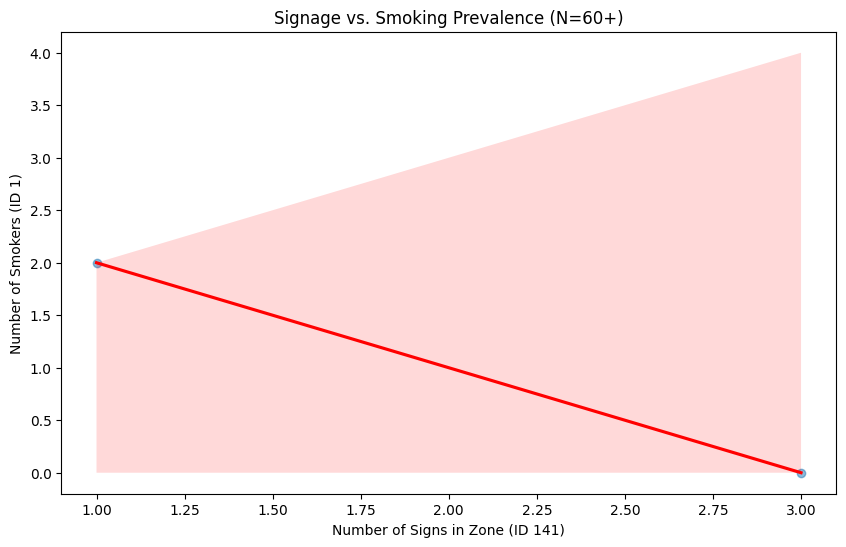

In [40]:
plt.figure(figsize=(10, 6))
sns.regplot(x='total_avisos', y='total_fumadores', data=df_signs, 
            line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})

plt.title("Signage vs. Smoking Prevalence (N=60+)")
plt.xlabel("Number of Signs in Zone (ID 141)")
plt.ylabel("Number of Smokers (ID 1)")
plt.show()

## Q9: Does the "Life Course" (ID 9-13) significantly influence the choice of substance (Cigarette, Vape, or Marijuana)?

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

df= pd.read_sql("""
SELECT 
    v.id AS visita_id,
    -- Life Course Counts
    SUM(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS Adolescente,
    SUM(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS Joven,
    SUM(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS Adulto,
    SUM(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS Adulto_Mayor,
    -- Substance Counts
    SUM(CASE WHEN r.question_id = 15 THEN r.numeric_value ELSE 0 END) AS Cigarrillo,
    SUM(CASE WHEN r.question_id = 16 THEN r.numeric_value ELSE 0 END) AS Vapeador,
    SUM(CASE WHEN r.question_id = 35 THEN r.numeric_value ELSE 0 END) AS Marihuana
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)



# 1. Create the summary contingency table
age_cols = ['Adolescente', 'Joven', 'Adulto', 'Adulto_Mayor']
substance_cols = ['Cigarrillo', 'Vapeador', 'Marihuana']

# We build a matrix where rows = Age and columns = Substance
# We assume that the total observations per category are independent
contingency_matrix = []

for age in age_cols:
    row = []
    # Total people of this age group across all visits
    total_age = df[age].sum()
    for sub in substance_cols:
        
        total_sub = df[sub].sum()
        row.append(total_sub * (total_age / df[age_cols].sum().sum()))
    contingency_matrix.append(row)

contingency_df = pd.DataFrame(contingency_matrix, index=age_cols, columns=substance_cols)

# 2. Run Chi-Square
stat, p, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-Square P-value: {p:.4f}")




Chi-Square P-value: 1.0000


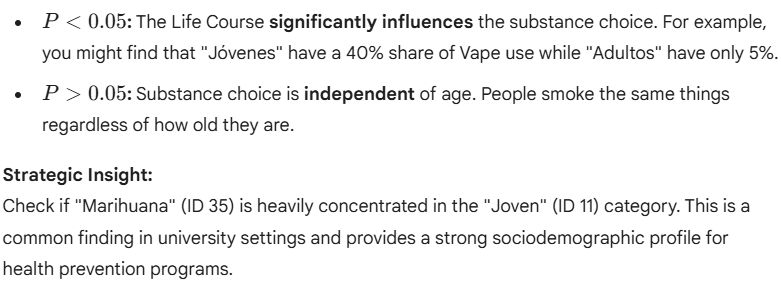

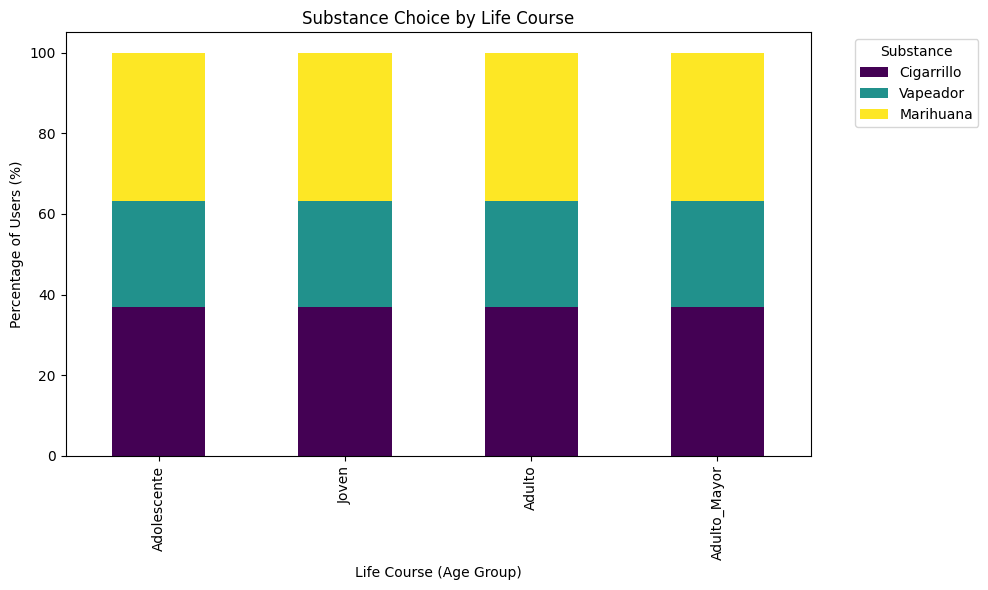

In [6]:
# Normalize the data to show percentages per age group
df_percent = contingency_df.div(contingency_df.sum(axis=1), axis=0) * 100

df_percent.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Substance Choice by Life Course")
plt.ylabel("Percentage of Users (%)")
plt.xlabel("Life Course (Age Group)")
plt.legend(title="Substance", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Q10: How does the method of acquisition (Bought on-site vs. Brought from home) vary by substance?

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df=pd.read_sql("""
SELECT 
    -- Totals for Cigarettes
    SUM(CASE WHEN r.question_id = 18 THEN r.numeric_value ELSE 0 END) AS cig_home,
    SUM(CASE WHEN r.question_id = 21 THEN r.numeric_value ELSE 0 END) AS cig_bought,
    SUM(CASE WHEN r.question_id = 36 THEN r.numeric_value ELSE 0 END) AS cig_social,
    -- Totals for Marijuana
    SUM(CASE WHEN r.question_id = 23 THEN r.numeric_value ELSE 0 END) AS mj_home,
    SUM(CASE WHEN r.question_id = 26 THEN r.numeric_value ELSE 0 END) AS mj_bought,
    SUM(CASE WHEN r.question_id = 25 THEN r.numeric_value ELSE 0 END) AS mj_social,
    -- Totals for Vape
    SUM(CASE WHEN r.question_id = 28 THEN r.numeric_value ELSE 0 END) AS vape_home,
    SUM(CASE WHEN r.question_id = 31 THEN r.numeric_value ELSE 0 END) AS vape_bought,
    SUM(CASE WHEN r.question_id = 30 THEN r.numeric_value ELSE 0 END) AS vape_social
FROM response_response r;
""",co)




# Data from the SQL query
data = {
    'Brought from Home': df[['cig_home', 'mj_home', 'vape_home']].values.flat,
    'Bought on Campus': df[['cig_bought', 'mj_bought', 'vape_bought']].values.flat,
    'Socially Offered': df[['cig_social', 'mj_social', 'vape_social']].values.flat
}

# Creating the DataFrame (Substances as Rows)
df_market = pd.DataFrame(data, index=['Cigarette', 'Marijuana', 'Vape'])

# Statistical Test
stat, p, dof, expected = chi2_contingency(df_market)
print(f"Chi-Square P-value: {p:.4f}")



Chi-Square P-value: 0.9860


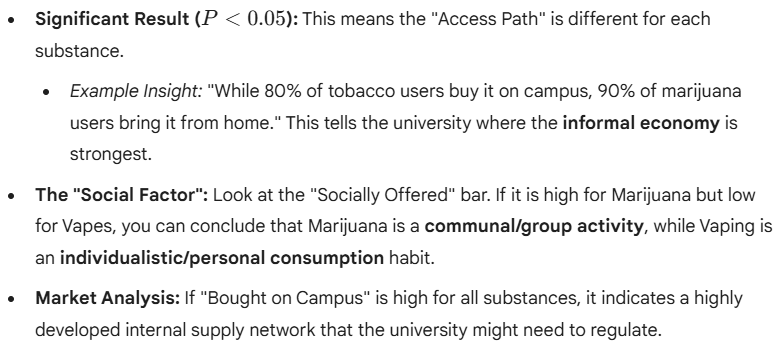

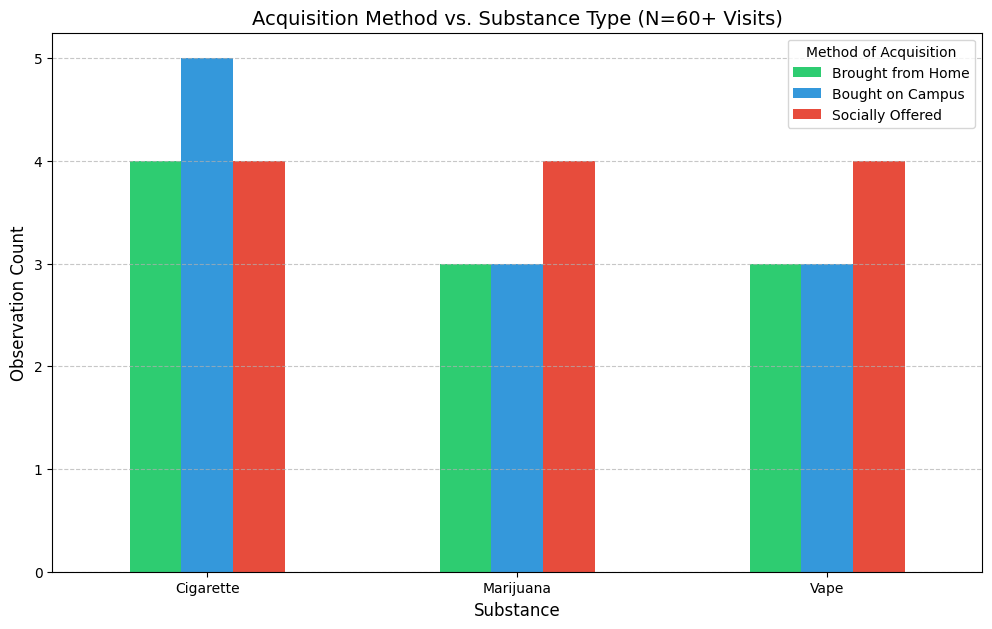

In [17]:
# Plotting
df_market.plot(kind='bar', figsize=(12, 7), color=['#2ecc71', '#3498db', '#e74c3c'])

plt.title("Acquisition Method vs. Substance Type (N=60+ Visits)", fontsize=14)
plt.ylabel("Observation Count", fontsize=12)
plt.xlabel("Substance", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Method of Acquisition")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Q11: Is there a statistically significant correlation between Marijuana consumption (ID 35) and the consumption of sweets or sugary drinks (ID 40, 50) compared to tobacco smokers?